https://www.kaggle.com/datasets/chebotinaa/fast-food-marketing-campaign-ab-test/data

In [1]:
import os
import dotenv
import kagglehub
import pandas as pd
import shutil
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from statsmodels.graphics.mosaicplot import mosaic
from scipy.stats import chisquare

In [2]:
def read_data():
    data_dir = "./data"
    os.makedirs(data_dir, exist_ok = True)
    try:
        data = pd.read_csv(f"{data_dir}/fast_food_marketing_campaign_ab_test.csv")
    except FileNotFoundError:
        # Download from Kaggle and save to data directory
        dotenv.load_dotenv(dotenv.find_dotenv())
        kagglehub.login()
        kagglehub.dataset_download("chebotinaa/fast-food-marketing-campaign-ab-test",
                                   output_dir = data_dir,
                                   force_download = True)
        data = pd.read_csv(f"{data_dir}/WA_Marketing-Campaign.csv")
        data.to_csv(f"{data_dir}/fast_food_marketing_campaign_ab_test.csv", index = False)
        
        # # Clean up downloaded files
        base_dir = Path.cwd().resolve().parent / "ab_testing/data"
        print(base_dir)
        targets = [base_dir / "WA_Marketing-Campaign.csv", base_dir / ".complete"]

        for target in targets:
            if target.is_dir():
                shutil.rmtree(target)
            elif target.exists():
                target.unlink()
            else:
                print(f"Not found: {target}")
    data.columns = data.columns.str.lower()
    return data

data = read_data()
data["market_location_id"] = data["marketid"].astype(str) + "-" + data["locationid"].astype(str)

## 0. Initial checks and randomization unit

Before diving into the analysis, a few sanity checks to confirm the data is in the expected shape:

- **No missing values** anywhere in the dataset
- **Location IDs are globally unique**: the same `locationid` does not repeat across different markets
- **Consistent time coverage**: every location has exactly 4 weeks of data
- **Clean group assignment**: no store participates in more than one promotion group

In [ ]:
# Missing values, uniqueness of location IDs, and consistency of timeframes
print(f"Are there null values in the dataset? --> {data.isnull().sum().any()}")
print("Independently of the market, is the location ID unique? --> "\
      f"{len(data['market_location_id'].unique()) == len(data['locationid'].unique())}")
print("Do all locations have the same timeframe? (4 weeks) --> "\
      f"{(data.groupby("market_location_id")["promotion"].size() == 4).all()}")

# Checking if there are stores that appear in multiple groups
which_in_both = data.groupby("market_location_id")["promotion"].nunique().gt(1)
which_in_both = which_in_both[which_in_both].index.tolist()
total_users = data["market_location_id"].nunique()
print("\nStores in multiple groups VS total: "\
      f"{len(which_in_both)} / {total_users} ({len(which_in_both) / total_users:.2%})")
print("Stores participating in each promotion: "\
      f"{data.groupby('promotion')['market_location_id'].nunique().to_dict()}")
print("Markets participating in each promotion: "\
      f"{data.groupby(['promotion'])['marketid'].nunique().to_dict()}")

Are there null values in the dataset? --> False
Independently of the market, is the location ID unique? --> True
Do all locations have the same timeframe? (4 weeks) --> True

Stores in multiple groups VS total: 0 / 137 (0.00%)
Stores participating in each promotion: {1: 43, 2: 47, 3: 47}
Markets participating in each promotion: {1: 10, 2: 9, 3: 10}


Store and market counts are close but not perfectly balanced: **43 / 47 / 47** stores and **10 / 9 / 10** markets per promotion. Promotion 2 covers one fewer market — something we'll revisit shortly.

To understand *how* the randomization was structured, we look at the joint distribution of stores across markets and promotions with a mosaic plot:

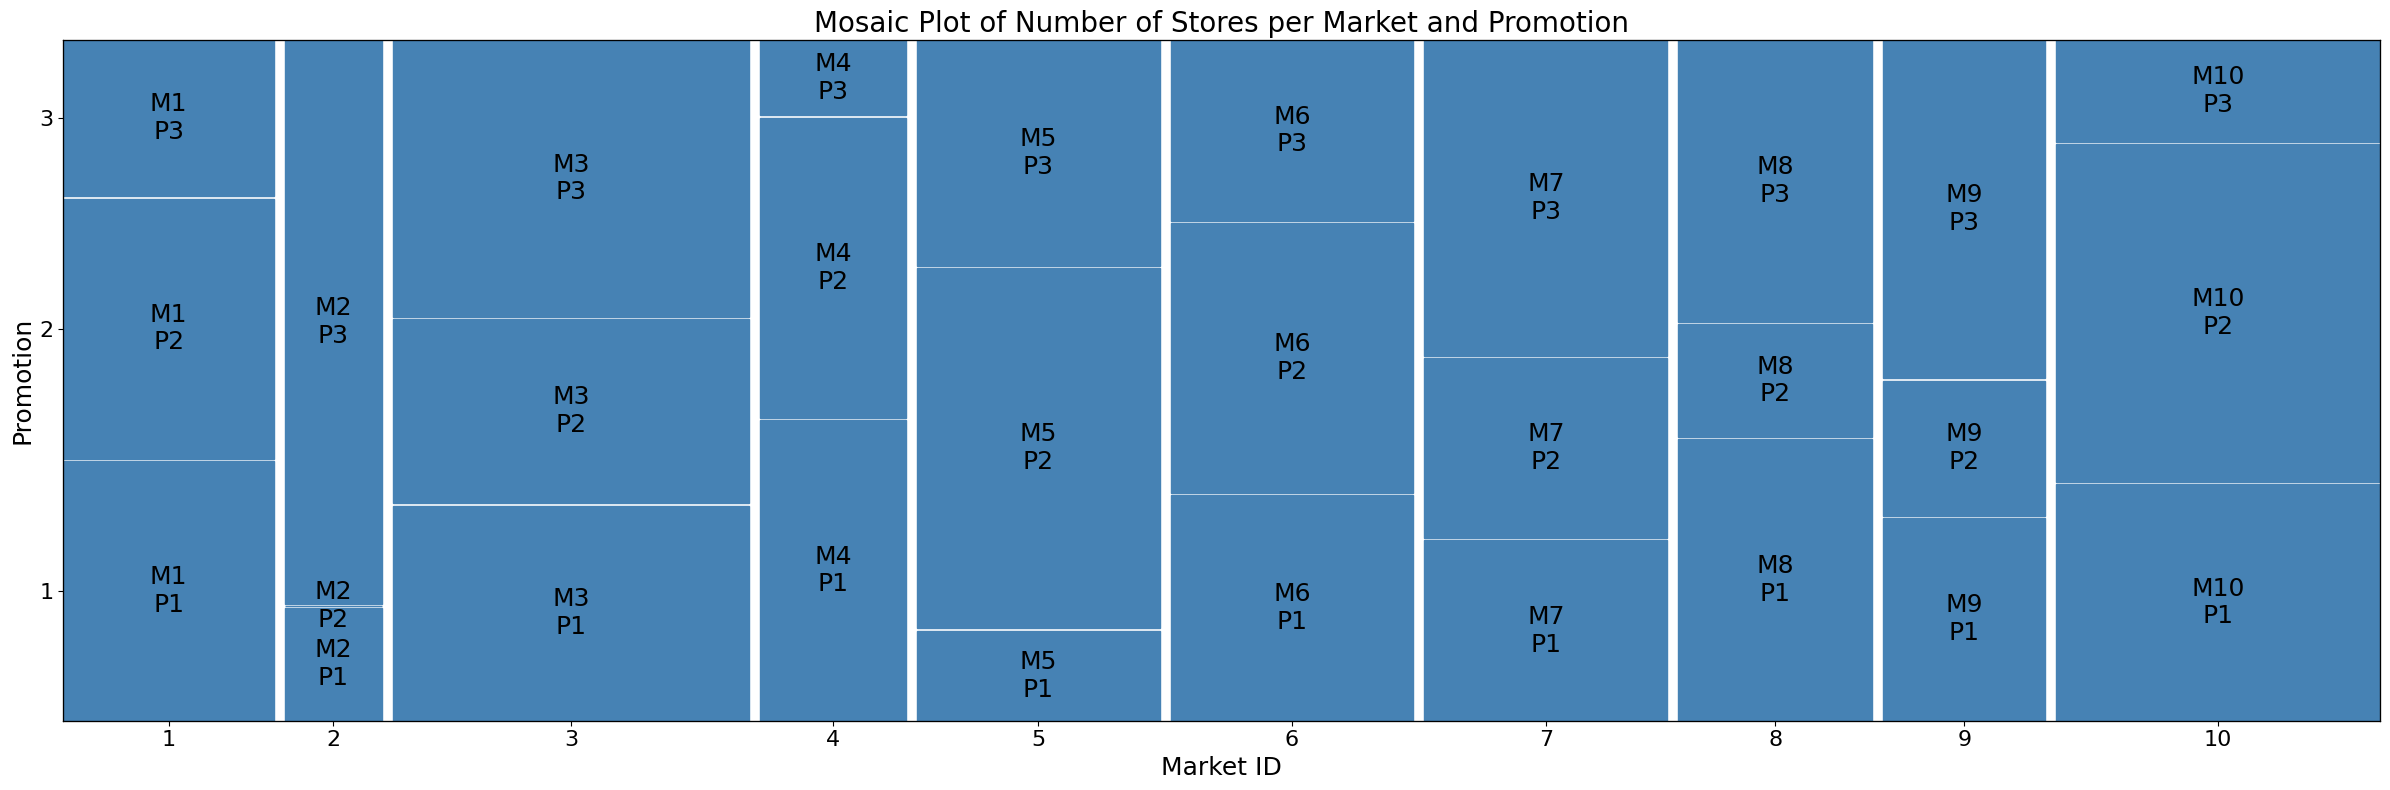

In [ ]:
# Prepare data for mosaic plot
mosaic_data = data.groupby(["marketid", "promotion"])["locationid"].nunique().reset_index()
mosaic_data.columns = ["marketid", "promotion", "num_stores"]
mosaic_data = mosaic_data.pivot(index = "marketid", columns = "promotion", values = "num_stores").fillna(0)

# Create mosaic plot
fig, ax = plt.subplots(figsize = (24, 8))
mosaic(
    mosaic_data.stack(),
    ax = ax,
    labelizer = lambda k: f"M{k[0]}\nP{k[1]}",
    properties = lambda k: {"color": "steelblue"},
)
for text in ax.texts:
    text.set_fontsize(18)
ax.set_xlabel("Market ID", fontsize = 18)
ax.set_ylabel("Promotion", fontsize = 18)

ax.set_title("Mosaic Plot of Number of Stores per Market and Promotion", fontsize = 20)
ax.tick_params(axis = "both", labelsize = 16)
plt.tight_layout()
plt.show()

The mosaic plot reveals two things:

- **Market size varies significantly** (tile *width* = share of total stores per market). Market 3 is the largest with 22 stores; market 2 is the smallest with only 6.
- **Within each market, stores are unevenly split across promotions** (tile *height* = conditional distribution given the market). Market 1 is the most balanced (5 / 5 / 3); markets 2 and 5 show the strongest imbalance — most notably, market 2 has **zero stores assigned to promotion 2**.

This uneven within-market allocation confirms that **randomization was done at the store (location) level**, not at the market level. It also explains why promotion 2 reaches only 9 out of 10 markets: during randomization, market 2 happened to receive no stores under that promotion.

A natural improvement would be **stratified randomization by market**: randomize store assignments *within* each market to guarantee a roughly equal split across every stratum. Without it, a larger market can end up over-represented in one promotion which, if markets differ systematically in baseline sales, could bias the overall comparison.

### 0.1. Analysis on probable intoxication due to chosen randomization
Without pre-experiment data we can't observe true baselines. As a rough proxy, we average per-store weekly sales across all promotions within each market. The caveat: since interventions are already running, this blends all promotion effects.

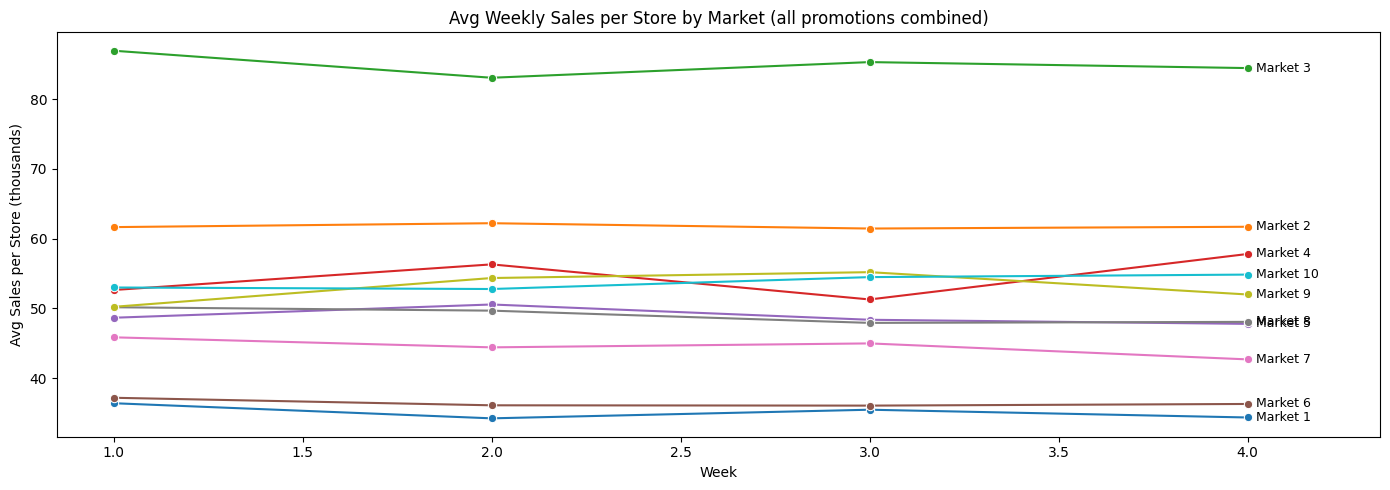

In [ ]:
market_weekly_avg = data.groupby(["marketid", "week"])["salesinthousands"].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(
    data = market_weekly_avg, x = "week", y = "salesinthousands",
    hue = "marketid", marker = "o", ax = ax, legend = False,
    palette = sns.color_palette("tab10", n_colors = market_weekly_avg["marketid"].nunique()),
)

for market_id, group in market_weekly_avg.groupby("marketid"):
    last = group.loc[group["week"].idxmax()]
    ax.annotate(
        f"Market {int(market_id)}",
        xy = (last["week"], last["salesinthousands"]),
        xytext = (6, 0),
        textcoords = "offset points",
        va = "center",
        fontsize = 9,
    )

ax.set_xlim(right = ax.get_xlim()[1] + 0.2)
ax.set_title("Avg Weekly Sales per Store by Market (all promotions combined)")
ax.set_xlabel("Week")
ax.set_ylabel("Avg Sales per Store (thousands)")
plt.tight_layout()
plt.show()

In [30]:
data[["marketid", "marketsize"]].drop_duplicates().to_dict(orient = "records")

[{'marketid': 1, 'marketsize': 'Medium'},
 {'marketid': 2, 'marketsize': 'Small'},
 {'marketid': 3, 'marketsize': 'Large'},
 {'marketid': 4, 'marketsize': 'Small'},
 {'marketid': 5, 'marketsize': 'Medium'},
 {'marketid': 6, 'marketsize': 'Medium'},
 {'marketid': 7, 'marketsize': 'Medium'},
 {'marketid': 8, 'marketsize': 'Medium'},
 {'marketid': 9, 'marketsize': 'Medium'},
 {'marketid': 10, 'marketsize': 'Large'}]

The second chart breaks the same metric down by promotion within each market — this is where the stratification risk becomes concrete. If markets with systematically higher (or lower) sales are over-represented in a specific promotion, the group averages are not comparing like for like.

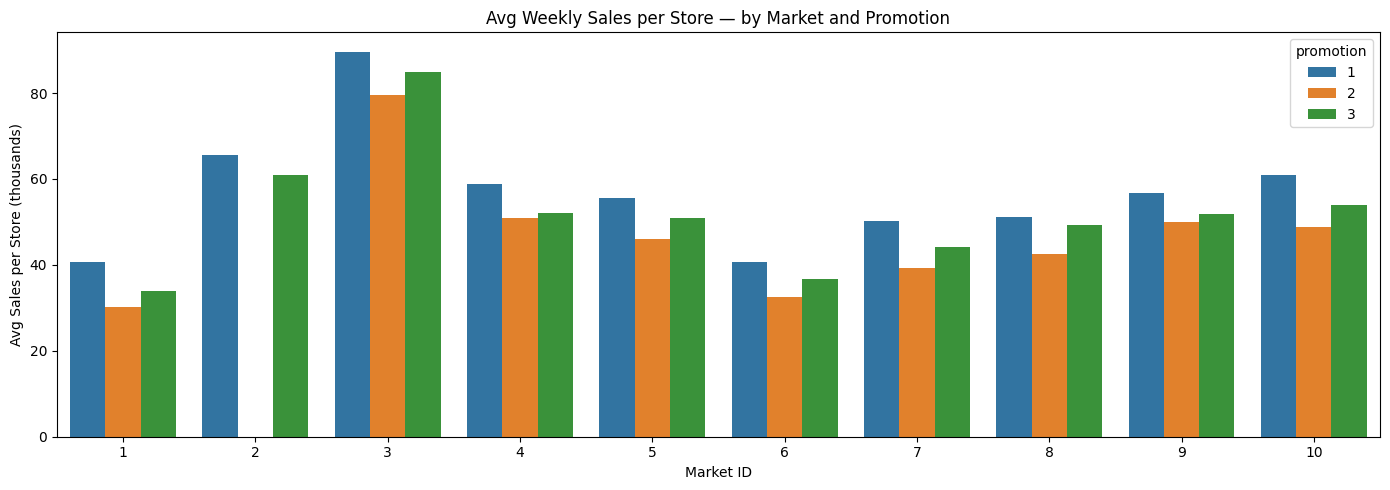

In [ ]:
# Average weekly sales per store, by market and promotion
# (each row in `data` is already one store × one week, so .mean() gives per-store average)
market_promo_avg = data.groupby(["marketid", "promotion"])["salesinthousands"].mean().reset_index()
market_promo_avg["promotion"] = market_promo_avg["promotion"].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data = market_promo_avg, x = "marketid", y = "salesinthousands", hue = "promotion",
            ax = ax)
ax.set_title("Avg Weekly Sales per Store — by Market and Promotion")
ax.set_xlabel("Market ID")
ax.set_ylabel("Avg Sales per Store (thousands)")
plt.tight_layout()
plt.show()

## 1. Sample ratio mismatch

In [6]:
srm_alpha = 0.001
def sample_ratio_mismatch_test(data, group_col, id_col, alpha = 0.001):
    observed = data.groupby(group_col)[id_col].nunique().tolist()
    expected = [sum(observed) / len(observed)] * len(observed)
    _, p_value = chisquare(f_obs = observed, f_exp = expected)
    if p_value < alpha:
        print(f"The groups are not equally distributed (p = {p_value:.4f} < {alpha})")
    else:
        print(f"The groups are equally distributed (p = {p_value:.4f} >= {alpha})")
    return p_value

p_value = sample_ratio_mismatch_test(data, "promotion", "market_location_id")

The groups are equally distributed (p = 0.8898 >= 0.001)


## 1. Analysis